In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Volume size ~ real data
VOXEL_SIZE = (0.096, 0.096, 1.0)   # (µm_x, µm_y, µm_z)
VOL_SHAPE  = (64, 128, 128)        # (z, y, x)

N_SYNAPSES = 2000                  # dense
RADIUS_VOX = (1.0, 1.0, 1.0)       # ~1 voxel radius

In [ ]:
def make_synthetic_volume(vol_shape, n_synapses, radius_vox):
    zdim, ydim, xdim = vol_shape
    label_vol = np.zeros(vol_shape, dtype=np.int32)
    clean_vol = np.zeros(vol_shape, dtype=np.float32)

    zz, yy, xx = np.meshgrid(
        np.arange(zdim), np.arange(ydim), np.arange(xdim), indexing='ij'
    )

    for syn_id in range(1, n_synapses + 1):
        cz = np.random.randint(2, zdim - 2)
        cy = np.random.randint(2, ydim - 2)
        cx = np.random.randint(2, xdim - 2)
        rz, ry, rx = radius_vox

        dz = (zz - cz) / rz
        dy = (yy - cy) / ry
        dx = (xx - cx) / rx
        dist2 = dz**2 + dy**2 + dx**2

        # Gaussian blob; random peak intensity
        peak = np.random.uniform(0.5, 1.0)
        blob = peak * np.exp(-0.5 * dist2)

        # Update clean volume (max to allow overlaps)
        clean_vol = np.maximum(clean_vol, blob)

        # Instance labels: assign syn_id where blob significant
        label_vol[(blob > 0.3) & (label_vol == 0)] = syn_id

    # Normalize to [0,1]
    clean_vol = (clean_vol - clean_vol.min()) / (clean_vol.max() + 1e-8)
    return clean_vol, label_vol

clean_vol, label_vol = make_synthetic_volume(VOL_SHAPE, N_SYNAPSES, RADIUS_VOX)

In [ ]:
import scipy.ndimage as ndi

def simulate_2p_from_airyscan(clean_vol):
    # Anisotropic blur: more blur in z
    sigma = (1.5, 0.8, 0.8)  # (z, y, x)
    blurred = ndi.gaussian_filter(clean_vol, sigma=sigma)

    # Add Poisson-like noise
    lam = 20.0
    scaled = blurred * lam
    noisy = np.random.poisson(scaled).astype(np.float32) / lam

    # Add Gaussian read noise
    noisy += np.random.normal(0, 0.05, size=noisy.shape).astype(np.float32)

    # Clip and normalize
    noisy = np.clip(noisy, 0, None)
    noisy = (noisy - noisy.min()) / (noisy.max() + 1e-8)
    return noisy

raw_2p = simulate_2p_from_airyscan(clean_vol)

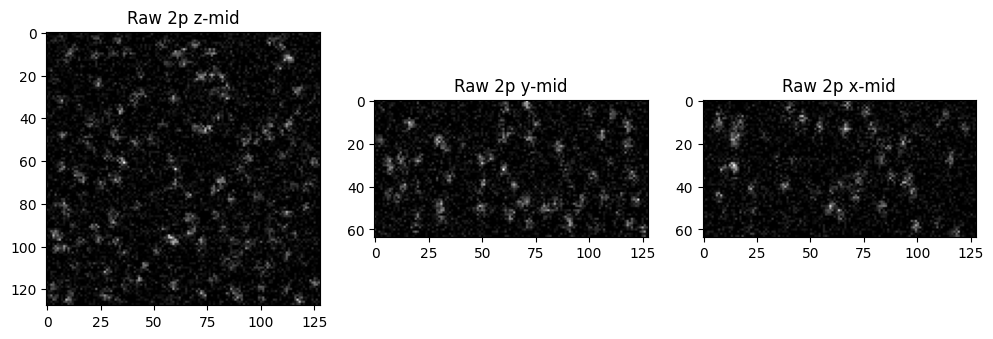

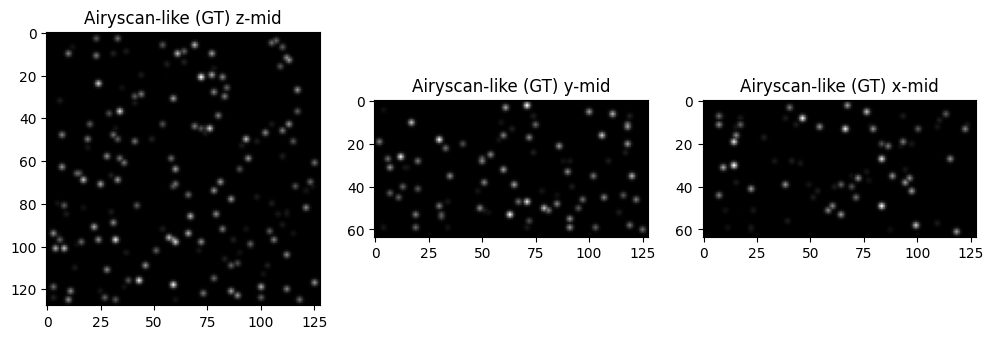

In [ ]:
def show_slices(vol, title):
    zmid = vol.shape[0] // 2
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(vol[zmid], cmap='gray'); plt.title(f'{title} z-mid')
    plt.subplot(1,3,2); plt.imshow(vol[:, vol.shape[1]//2, :], cmap='gray'); plt.title(f'{title} y-mid')
    plt.subplot(1,3,3); plt.imshow(vol[:, :, vol.shape[2]//2], cmap='gray'); plt.title(f'{title} x-mid')
    plt.show()

show_slices(raw_2p, 'Raw 2p')
show_slices(clean_vol, 'Airyscan-like (GT)')


Simple 3D U‑Net

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet3D(nn.Module):
    def __init__(self, base_ch=16):
        super().__init__()
        self.enc1 = ConvBlock3D(1, base_ch)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = ConvBlock3D(base_ch, base_ch*2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = ConvBlock3D(base_ch*2, base_ch*4)

        self.up2 = nn.ConvTranspose3d(base_ch*4, base_ch*2, 2, stride=2)
        self.dec2 = ConvBlock3D(base_ch*4, base_ch*2)
        self.up1 = nn.ConvTranspose3d(base_ch*2, base_ch, 2, stride=2)
        self.dec1 = ConvBlock3D(base_ch*2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))
        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        out = self.out_conv(d1)
        return torch.sigmoid(out)

model_xtc = UNet3D().cuda()


In [ ]:
from torch.utils.data import Dataset, DataLoader

PATCH_SIZE = (32, 64, 64)  # smaller to fit GPU

def extract_patches(vol_in, vol_gt, patch_size, stride):
    patches_in, patches_gt = [], []
    zps, yps, xps = patch_size
    sz, sy, sx = stride
    zdim, ydim, xdim = vol_in.shape
    for z in range(0, zdim - zps + 1, sz):
        for y in range(0, ydim - yps + 1, sy):
            for x in range(0, xdim - xps + 1, sx):
                patches_in.append(vol_in[z:z+zps, y:y+yps, x:x+xps])
                patches_gt.append(vol_gt[z:z+zps, y:y+yps, x:x+xps])
    return np.stack(patches_in), np.stack(patches_gt)

patches_in, patches_gt = extract_patches(
    raw_2p, clean_vol, PATCH_SIZE, stride=(16, 32, 32)
)

class PairedVolumeDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.from_numpy(x[:, None]).float()  # add channel
        self.y = torch.from_numpy(y[:, None]).float()
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

dataset = PairedVolumeDataset(patches_in, patches_gt)
loader = DataLoader(dataset, batch_size=2, shuffle=True)


In [ ]:
optimizer = torch.optim.Adam(model_xtc.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(20):  # define no of epochs
    model_xtc.train()
    running_loss = 0.0
    for xb, yb in loader:
        xb = xb.cuda()
        yb = yb.cuda()

        optimizer.zero_grad()
        pred = model_xtc(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    print(f"Epoch {epoch+1}, loss = {running_loss/len(dataset):.4f}")


Epoch 1, loss = 0.2274
Epoch 2, loss = 0.1821
Epoch 3, loss = 0.1612
Epoch 4, loss = 0.1436
Epoch 5, loss = 0.1291
Epoch 6, loss = 0.1165
Epoch 7, loss = 0.1053
Epoch 8, loss = 0.0930
Epoch 9, loss = 0.0831
Epoch 10, loss = 0.0750
Epoch 11, loss = 0.0677
Epoch 12, loss = 0.0609
Epoch 13, loss = 0.0551
Epoch 14, loss = 0.0494
Epoch 15, loss = 0.0446
Epoch 16, loss = 0.0404
Epoch 17, loss = 0.0368
Epoch 18, loss = 0.0337
Epoch 19, loss = 0.0310
Epoch 20, loss = 0.0286


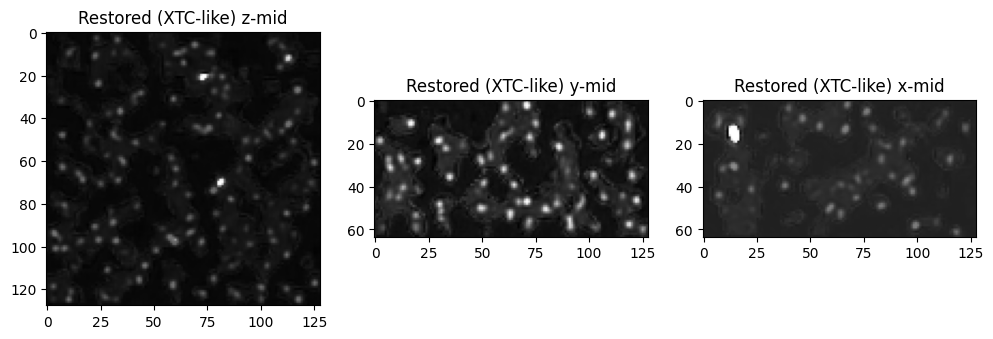

In [ ]:
model_xtc.eval()
with torch.no_grad():
    inp = torch.from_numpy(raw_2p[None, None]).float().cuda()
    restored = model_xtc(inp).cpu().numpy()[0,0]

show_slices(restored, "Restored (XTC-like)")


MR-CNN style instance segmentation + tracking

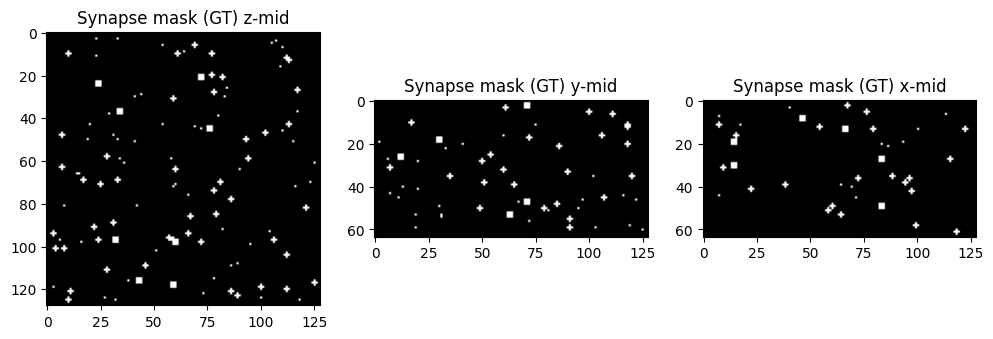

In [ ]:
syn_mask = (label_vol > 0).astype(np.float32)
show_slices(syn_mask, "Synapse mask (GT)")


In [ ]:
model_seg = UNet3D().cuda()
optimizer = torch.optim.Adam(model_seg.parameters(), lr=1e-3)
bce = nn.BCELoss()

# Reuse patch extraction but use restored volume & syn_mask
restored_np = restored  # from Step 2
patches_in2, patches_gt2 = extract_patches(
    restored_np, syn_mask, PATCH_SIZE, stride=(16, 32, 32)
)
dataset2 = PairedVolumeDataset(patches_in2, patches_gt2)
loader2  = DataLoader(dataset2, batch_size=2, shuffle=True)

for epoch in range(20):
    model_seg.train()
    running = 0.0
    for xb, yb in loader2:
        xb, yb = xb.cuda(), yb.cuda()
        optimizer.zero_grad()
        pred = model_seg(xb)
        loss = bce(pred, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    print(f"Seg Epoch {epoch+1}, loss = {running/len(dataset2):.4f}")


Seg Epoch 1, loss = 0.5482
Seg Epoch 2, loss = 0.4617
Seg Epoch 3, loss = 0.4161
Seg Epoch 4, loss = 0.3813
Seg Epoch 5, loss = 0.3535
Seg Epoch 6, loss = 0.3293
Seg Epoch 7, loss = 0.3073
Seg Epoch 8, loss = 0.2878
Seg Epoch 9, loss = 0.2706
Seg Epoch 10, loss = 0.2549
Seg Epoch 11, loss = 0.2406
Seg Epoch 12, loss = 0.2276
Seg Epoch 13, loss = 0.2158
Seg Epoch 14, loss = 0.2051
Seg Epoch 15, loss = 0.1951
Seg Epoch 16, loss = 0.1861
Seg Epoch 17, loss = 0.1775
Seg Epoch 18, loss = 0.1694
Seg Epoch 19, loss = 0.1620
Seg Epoch 20, loss = 0.1550


Predicted objects: 1542


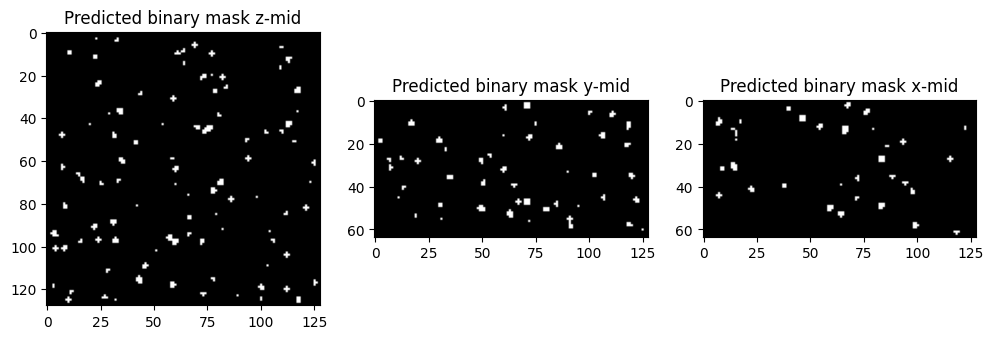

In [ ]:
model_seg.eval()
with torch.no_grad():
    inp = torch.from_numpy(restored_np[None, None]).float().cuda()
    prob = model_seg(inp).cpu().numpy()[0,0]

pred_bin = (prob > 0.5).astype(np.uint8)

import scipy.ndimage as ndi
pred_labels, n_obj = ndi.label(pred_bin)
print("Predicted objects:", n_obj)

show_slices(pred_bin, "Predicted binary mask")


In [ ]:
def get_centroids(label_vol):
    ids = np.unique(label_vol)
    ids = ids[ids != 0]
    centroids = {}
    for i in ids:
        coords = np.argwhere(label_vol == i)
        centroids[i] = coords.mean(axis=0)  # (z,y,x)
    return centroids


In [ ]:
from scipy.spatial import cKDTree

def match_tracks(labels_t, labels_tp1, max_dist=5.0):
    c_t = get_centroids(labels_t)
    c_tp1 = get_centroids(labels_tp1)
    if not c_t or not c_tp1:
        return {}

    ids_t   = np.array(list(c_t.keys()))
    pts_t   = np.stack([c_t[i] for i in ids_t])
    ids_tp1 = np.array(list(c_tp1.keys()))
    pts_tp1 = np.stack([c_tp1[i] for i in ids_tp1])

    tree = cKDTree(pts_tp1)
    dists, idxs = tree.query(pts_t)

    mapping = {}
    for i, d, j in zip(ids_t, dists, idxs):
        if d <= max_dist:
            mapping[i] = ids_tp1[j]
    return mapping


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline

# After Step 3 (you have restored_np, pred_bin, label_vol)
z_slider = widgets.IntSlider(min=0, max=restored_np.shape[0]-1, value=32, description='Z-slice')

def update_slice(z):
    fig, axs = plt.subplots(1,3, figsize=(15,4))
    axs[0].imshow(restored_np[z], cmap='gray'); axs[0].set_title('Restored')
    axs[1].imshow(pred_bin[z], cmap='Reds'); axs[1].set_title('Pred mask')
    axs[2].imshow(label_vol[z], cmap='viridis', vmin=0, vmax=50); axs[2].set_title('GT labels')
    plt.tight_layout(); plt.show()

widgets.interact(update_slice, z=z_slider)


interactive(children=(IntSlider(value=32, description='Z-slice', max=63), Output()), _dom_classes=('widget-int…

<function __main__.update_slice(z)>